In [45]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [46]:
# Load CSV dataset
df = pd.read_csv("COVID-19_Case_Surveillance_Public_Use_Data 3.csv", low_memory=False)

print("Original shape:", df.shape)
print(df.columns.tolist())
print(df.head())

Original shape: (8405079, 11)
['cdc_report_dt', 'pos_spec_dt', 'onset_dt', 'current_status', 'sex', 'age_group', 'Race and ethnicity (combined)', 'hosp_yn', 'icu_yn', 'death_yn', 'medcond_yn']
  cdc_report_dt pos_spec_dt    onset_dt             current_status   sex  \
0    2020/11/10  2020/11/10         NaN  Laboratory-confirmed case  Male   
1    2020/11/14  2020/11/10  2020/11/10  Laboratory-confirmed case  Male   
2    2020/11/19  2020/11/10  2020/11/09  Laboratory-confirmed case  Male   
3    2020/11/14  2020/11/10         NaN  Laboratory-confirmed case  Male   
4    2020/11/13  2020/11/10  2020/11/10  Laboratory-confirmed case  Male   

       age_group Race and ethnicity (combined)  hosp_yn   icu_yn death_yn  \
0  10 - 19 Years           Black, Non-Hispanic       No  Unknown       No   
1  10 - 19 Years           Black, Non-Hispanic       No       No       No   
2  10 - 19 Years           Black, Non-Hispanic       No       No       No   
3  10 - 19 Years           Black, Non-Hisp

In [47]:
# Keep useful columns
cols = [
    "current_status",
    "sex",
    "age_group",
    "Race and ethnicity (combined)",
    "hosp_yn",
    "icu_yn",
    "death_yn",
    "medcond_yn"
]

df = df[cols].copy()

In [48]:
# Clean data
df = df.replace(["Missing", "Unknown", "NA", ""], np.nan)

df = df.dropna(subset=["hosp_yn", "icu_yn", "death_yn"], how="all")

In [49]:
# Create target variable
df["severe"] = (
    (df["hosp_yn"] == "Yes") |
    (df["icu_yn"] == "Yes") |
    (df["death_yn"] == "Yes")
).astype(int)

print("Severe outcome distribution:")
print(df["severe"].value_counts())
print(df["severe"].value_counts(normalize=True))

Severe outcome distribution:
severe
0    4244703
1     609259
Name: count, dtype: int64
severe
0    0.874482
1    0.125518
Name: proportion, dtype: float64


In [50]:
# Sample data 
if len(df) > 200000:
    df = df.sample(n=200000, random_state=42)

print("Working shape:", df.shape)

Working shape: (200000, 9)


In [51]:
# Features and target
features = [
    "current_status",
    "sex",
    "age_group",
    "Race and ethnicity (combined)",
    "medcond_yn"
]

X = df[features]
y = df["severe"]

In [52]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [53]:
# Preprocessing
preprocessor = ColumnTransformer([
    ("cat",
     Pipeline([
         ("imputer", SimpleImputer(strategy="most_frequent")),
         ("onehot", OneHotEncoder(handle_unknown="ignore"))
     ]),
     features)
])

In [54]:
# Logistic Regression
lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1:", f1_score(y_test, pred_lr))

Logistic Regression
Accuracy: 0.7721
Recall: 0.7140309155766944
F1: 0.44149001347874034


In [55]:
# Decision Tree
dt = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=10, class_weight="balanced"))
])

dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print("Recall:", recall_score(y_test, pred_dt))
print("F1:", f1_score(y_test, pred_dt))

Decision Tree
Accuracy: 0.7519
Recall: 0.746730083234245
F1: 0.4316151202749141


In [56]:
# KNN
knn = Pipeline([
    ("prep", preprocessor),
    ("scale", StandardScaler(with_mean=False)),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print("KNN")
print("Accuracy:", accuracy_score(y_test, pred_knn))
print("Recall:", recall_score(y_test, pred_knn))
print("F1:", f1_score(y_test, pred_knn))

KNN
Accuracy: 0.878775
Recall: 0.1928260007927071
F1: 0.2863870493009566


In [57]:
# MLP
mlp = Pipeline([
    ("prep", preprocessor),
    ("scale", StandardScaler(with_mean=False)),
    ("model", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300))
])

mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

print("MLP")
print("Accuracy:", accuracy_score(y_test, pred_mlp))
print("Recall:", recall_score(y_test, pred_mlp))
print("F1:", f1_score(y_test, pred_mlp))

MLP
Accuracy: 0.881875
Recall: 0.1872770511296076
F1: 0.2857142857142857


In [58]:
# Compare models
results = pd.DataFrame({
    "Model": ["LR", "DT", "KNN", "MLP"],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_mlp)
    ],
    "Recall": [
        recall_score(y_test, pred_lr),
        recall_score(y_test, pred_dt),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_mlp)
    ],
    "F1": [
        f1_score(y_test, pred_lr),
        f1_score(y_test, pred_dt),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_mlp)
    ]
})

print("Model Comparison")
print(results.sort_values(by="F1", ascending=False))

Model Comparison
  Model  Accuracy    Recall        F1
0    LR  0.772100  0.714031  0.441490
1    DT  0.751900  0.746730  0.431615
2   KNN  0.878775  0.192826  0.286387
3   MLP  0.881875  0.187277  0.285714


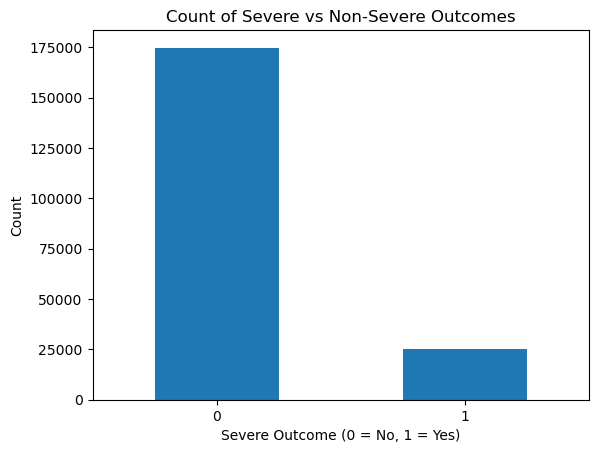

In [60]:
import matplotlib.pyplot as plt

# Graph 1
df["severe"].value_counts().sort_index().plot(kind="bar")
plt.title("Count of Severe vs Non-Severe Outcomes")
plt.xlabel("Severe Outcome (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

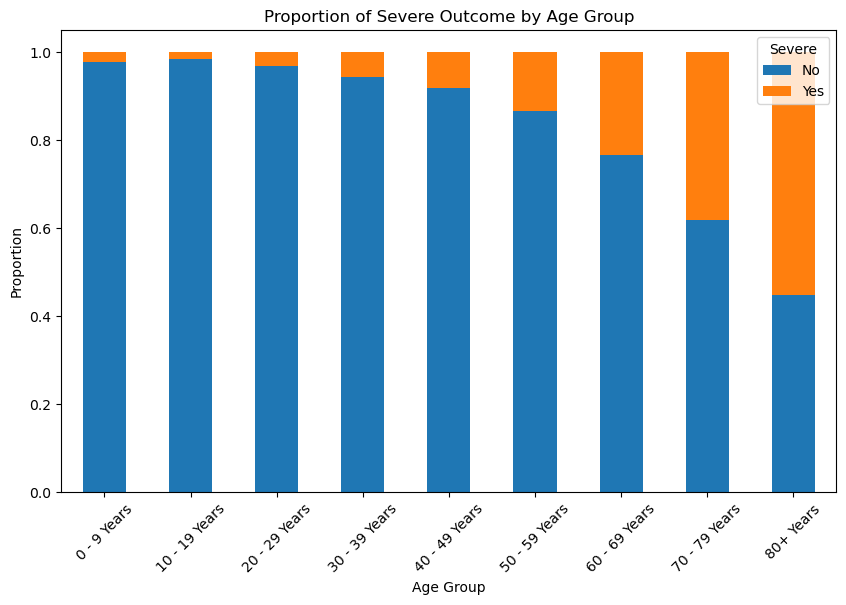

In [61]:
# Graph 2
age_severe = pd.crosstab(df["age_group"], df["severe"], normalize="index")
age_severe.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Proportion of Severe Outcome by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion")
plt.legend(title="Severe", labels=["No", "Yes"])
plt.xticks(rotation=45)
plt.show()

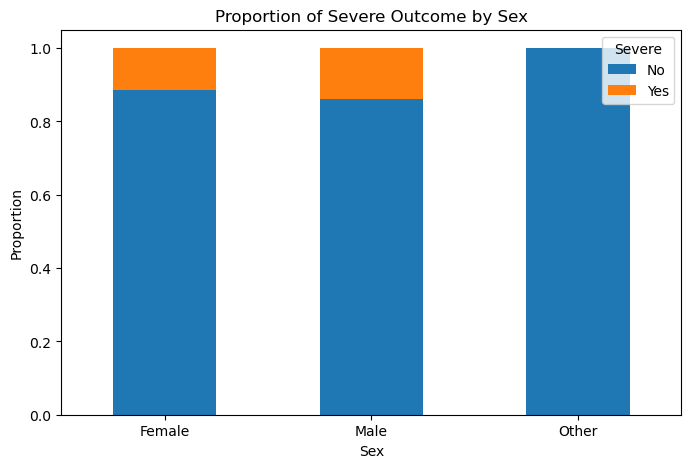

In [62]:
# Graph 3
sex_severe = pd.crosstab(df["sex"], df["severe"], normalize="index")
sex_severe.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Proportion of Severe Outcome by Sex")
plt.xlabel("Sex")
plt.ylabel("Proportion")
plt.legend(title="Severe", labels=["No", "Yes"])
plt.xticks(rotation=0)
plt.show()

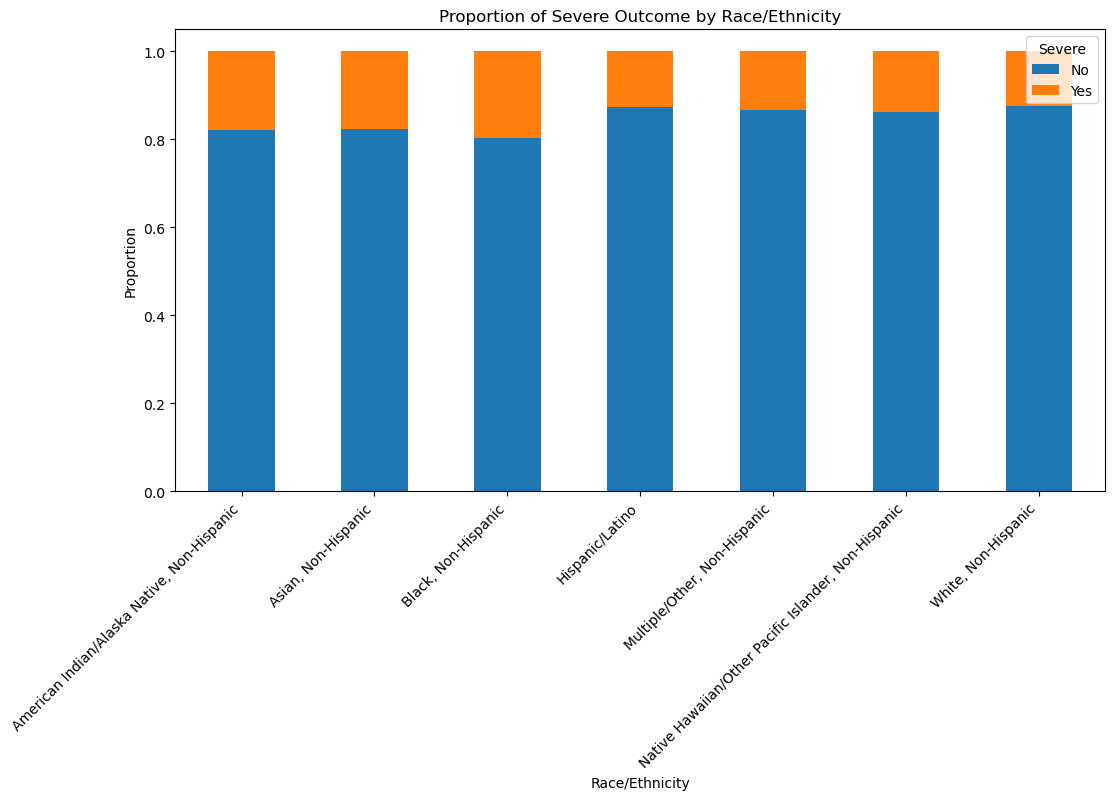

In [63]:
# Graph 4
race_severe = pd.crosstab(df["Race and ethnicity (combined)"], df["severe"], normalize="index")
race_severe.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Proportion of Severe Outcome by Race/Ethnicity")
plt.xlabel("Race/Ethnicity")
plt.ylabel("Proportion")
plt.legend(title="Severe", labels=["No", "Yes"])
plt.xticks(rotation=45, ha="right")
plt.show()